# Notebook 04 — Análise Comparativa de Sentimento: Atas COPOM

Este notebook unifica as bases de análise de sentimento das Atas do COPOM,
inserindo o score do modelo **Mistral** e comparando todos os modelos:
- **NLTK** (VADER)
- **TextBlob**
- **BERT** (BERTimbau)
- **FinBERT**
- **Mistral** (LLM)

Período: **2019 – 2025**

## 1. Imports e Configurações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

MODELOS = ['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']
LABELS  = ['NLTK (VADER)', 'TextBlob', 'BERT', 'FinBERT', 'Mistral']
CORES   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

## 2. Carregamento e Unificação das Bases

In [3]:
# Carrega base sem Mistral
df_base = pd.read_csv('base_sentimentos_copom_sem_mistral.csv')

# Carrega scores Mistral
df_mistral = pd.read_csv('base_sentimento_copom.csv')[['data', 'score']].rename(
    columns={'score': 'score_mistral'}
)

# Merge pela coluna 'data'
df = df_base.merge(df_mistral, on='data', how='left')

# Organiza colunas finais
df = df[['data', 'arquivo', 'tipo', 'score_nltk', 'score_textblob',
         'score_bert', 'score_finbert', 'score_mistral']]

# Converte data
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f'Registros: {len(df)}')
print(f'Período: {df.data.min().date()} → {df.data.max().date()}')
df.head()

Registros: 53
Período: 2019-02-06 → 2025-12-10


,data,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,COPOM220-not20190206220.pdf,copom,-0.7783,0.0000,-0.071429,-0.248734,0.50
1,2019-03-20,COPOM221-not20190320221.pdf,copom,-0.6808,0.0000,-0.062500,-0.336417,0.50
2,2019-05-08,COPOM222-not20190508222.pdf,copom,-0.9274,0.0625,-0.125000,-0.388865,0.65
3,2019-06-19,Copom223-not20190619223.pdf,copom,-0.7783,0.0000,-0.187500,-0.407422,0.75
4,2019-07-31,Copom224-not20190731224.pdf,copom,-0.8402,0.0000,0.062500,-0.227865,0.75


## 3. Estatísticas Descritivas

In [4]:
desc = df[MODELOS].describe().T
desc.index = LABELS
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4)

,mean,std,min,25%,50%,75%,max
NLTK (VADER),-0.8086,0.1096,-0.9517,-0.8807,-0.8402,-0.6808,-0.4939
TextBlob,0.0123,0.0611,-0.2667,0.0000,0.0000,0.0556,0.1667
BERT,-0.1695,0.1355,-0.4167,-0.2500,-0.1667,-0.0833,0.2500
FinBERT,-0.4044,0.0990,-0.5904,-0.4599,-0.4195,-0.3393,-0.2043
Mistral,0.2160,0.5608,-0.8500,-0.3000,0.4500,0.7000,0.8500


## 4. Evolução Temporal dos Scores

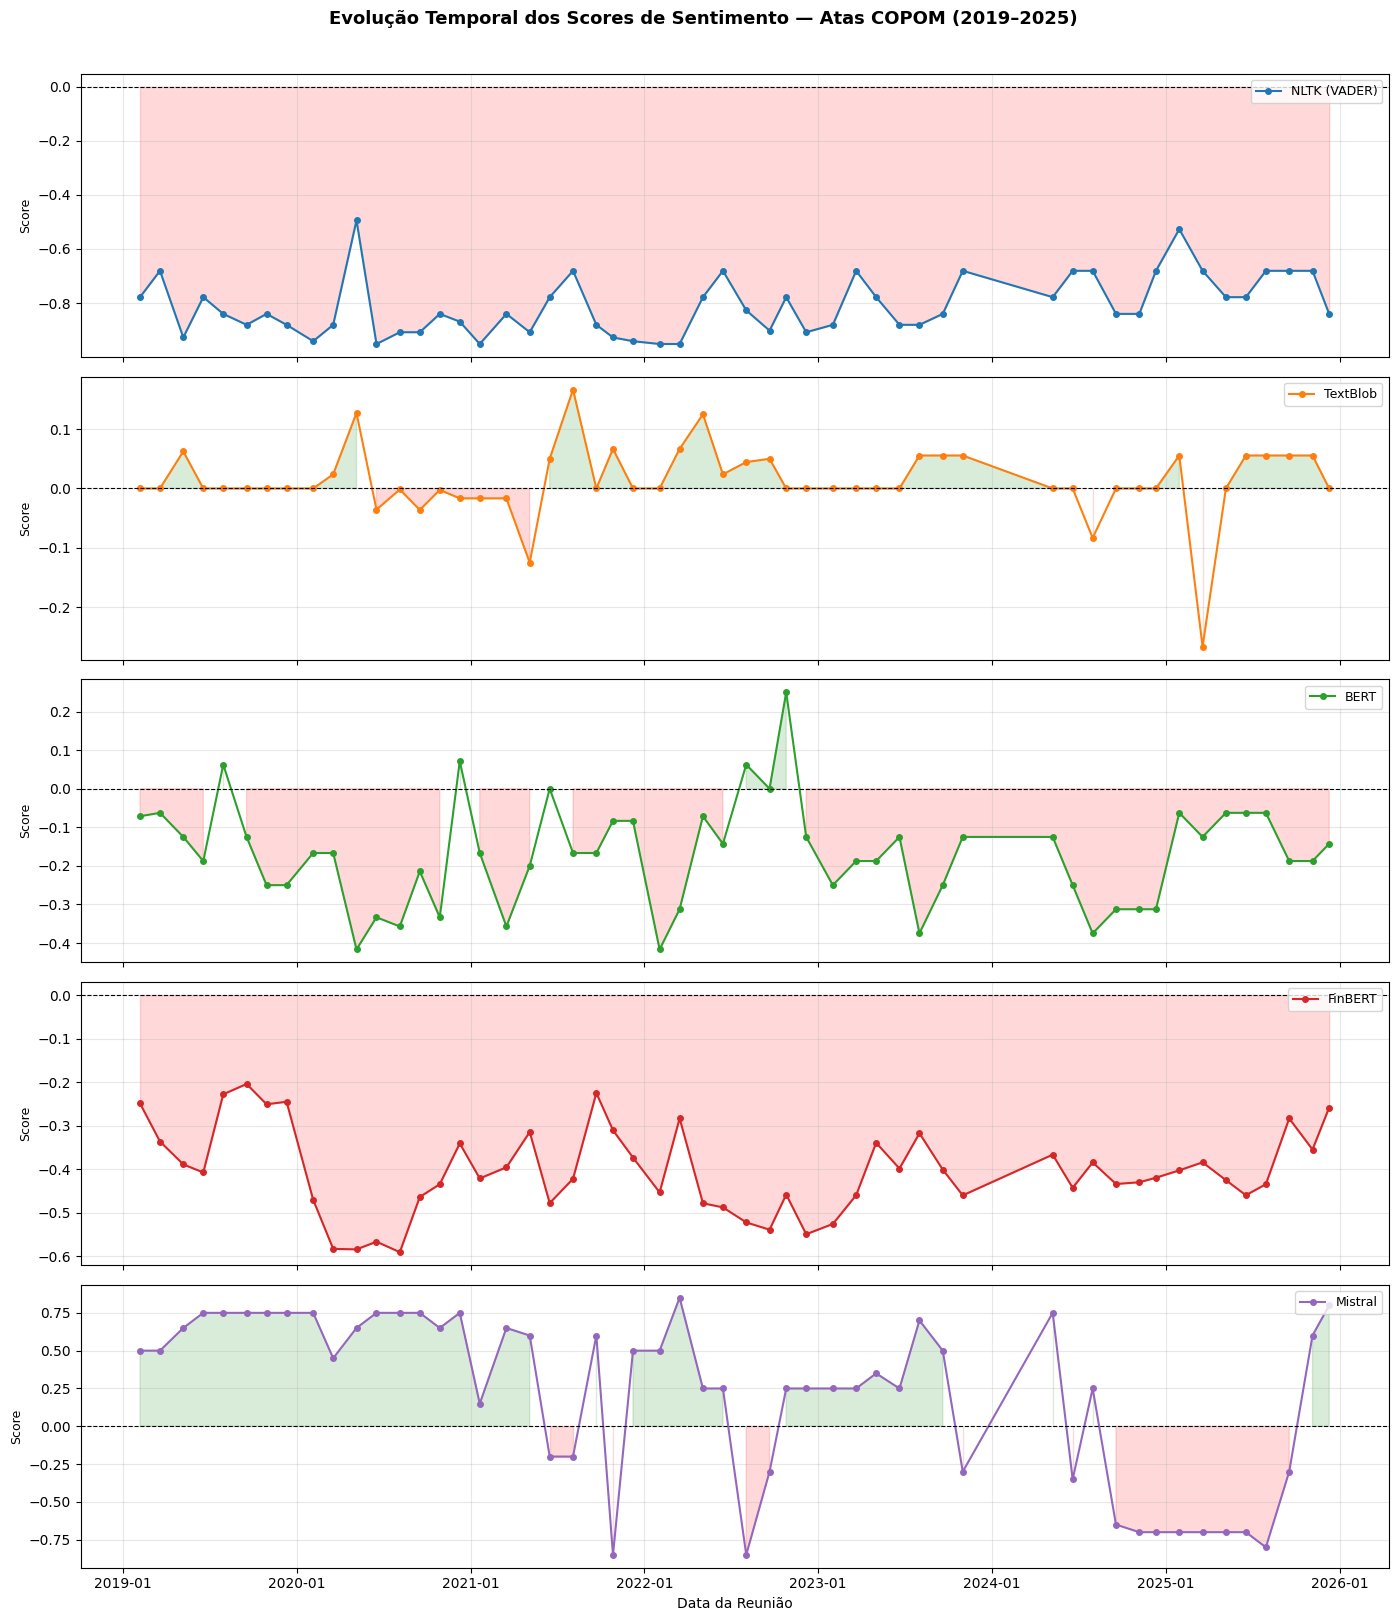

In [5]:
fig, axes = plt.subplots(len(MODELOS), 1, figsize=(14, 16), sharex=True)

for ax, col, label, cor in zip(axes, MODELOS, LABELS, CORES):
    ax.plot(df['data'], df[col], marker='o', markersize=4,
            linewidth=1.5, color=cor, label=label)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.fill_between(df['data'], df[col], 0,
                    where=df[col] >= 0, alpha=0.15, color='green')
    ax.fill_between(df['data'], df[col], 0,
                    where=df[col] < 0, alpha=0.15, color='red')
    ax.set_ylabel('Score', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[-1].set_xlabel('Data da Reunião')
fig.suptitle('Evolução Temporal dos Scores de Sentimento — Atas COPOM (2019–2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Comparativo Sobreposto

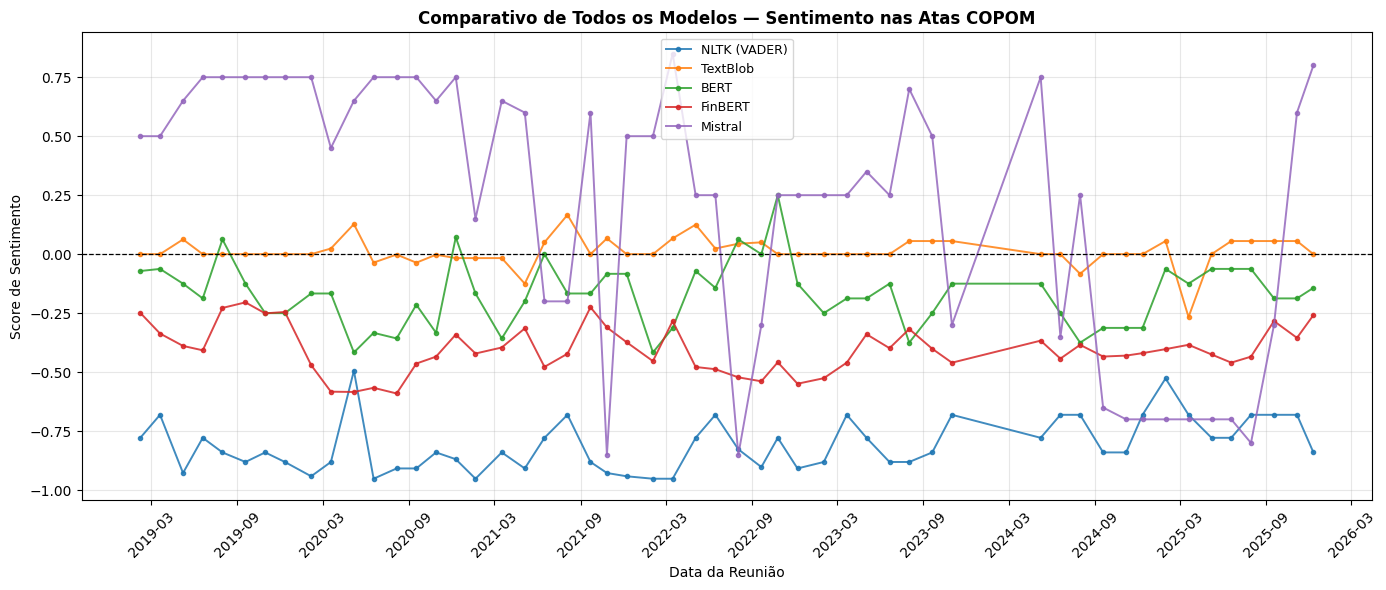

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

for col, label, cor in zip(MODELOS, LABELS, CORES):
    ax.plot(df['data'], df[col], marker='o', markersize=3,
            linewidth=1.4, label=label, color=cor, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('Comparativo de Todos os Modelos — Sentimento nas Atas COPOM',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data da Reunião')
ax.set_ylabel('Score de Sentimento')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Distribuição dos Scores por Modelo

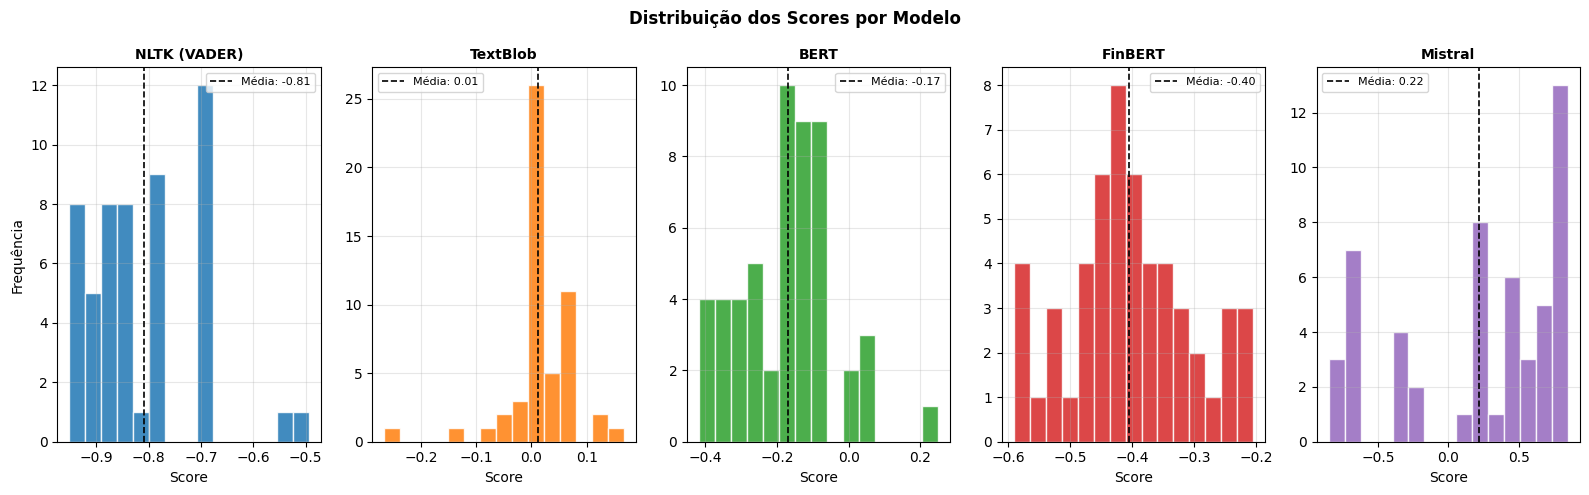

In [7]:
fig, axes = plt.subplots(1, len(MODELOS), figsize=(16, 5), sharey=False)

for ax, col, label, cor in zip(axes, MODELOS, LABELS, CORES):
    ax.hist(df[col], bins=15, color=cor, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--',
               linewidth=1.2, label=f'Média: {df[col].mean():.2f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frequência')
fig.suptitle('Distribuição dos Scores por Modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Boxplot Comparativo

/tmp/ipykernel_3646/91079229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Modelo', y='Score', palette=CORES, ax=ax)


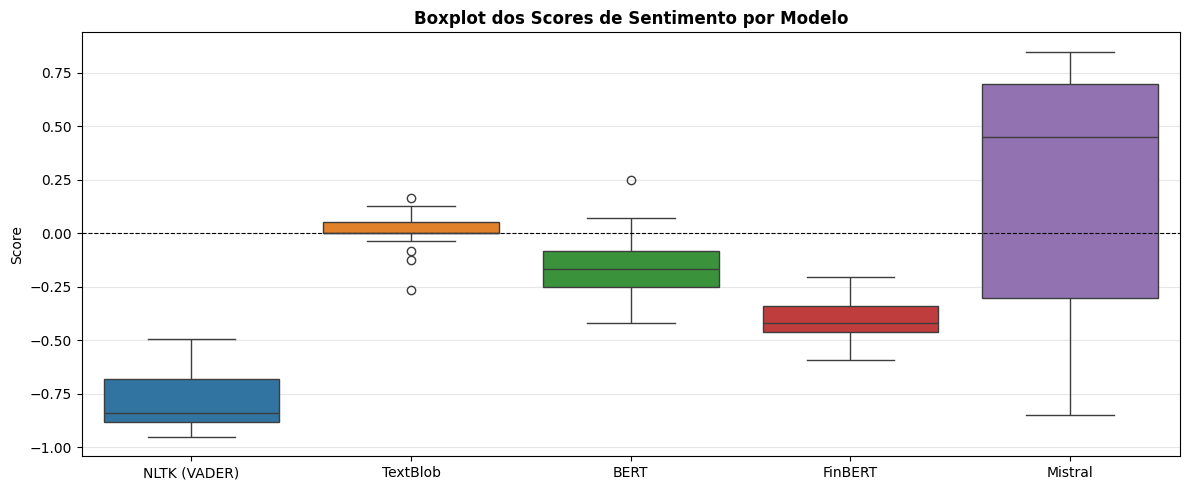

In [8]:
df_melt = df[MODELOS].copy()
df_melt.columns = LABELS
df_long = df_melt.melt(var_name='Modelo', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_long, x='Modelo', y='Score', palette=CORES, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Boxplot dos Scores de Sentimento por Modelo', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## 8. Correlação entre Modelos

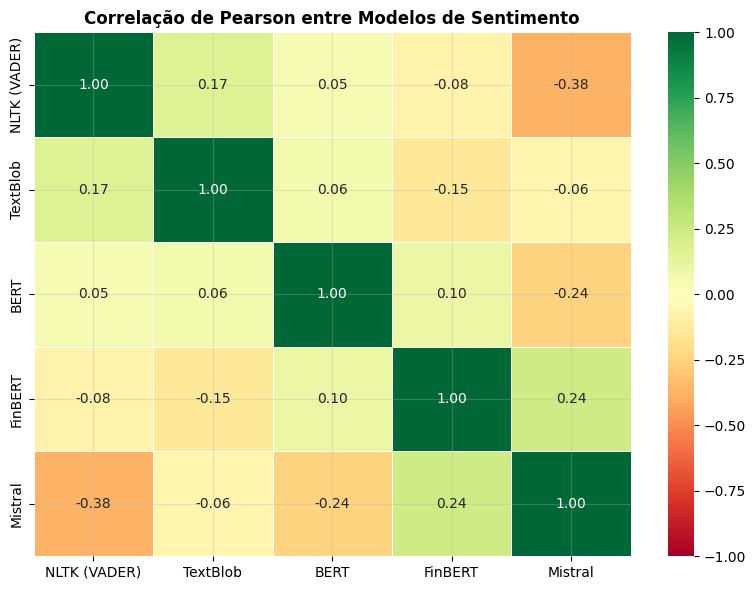

In [9]:
corr_matrix = df[MODELOS].corr(method='pearson')
corr_matrix.index   = LABELS
corr_matrix.columns = LABELS

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlação de Pearson entre Modelos de Sentimento',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Tabela de correlações: Pearson e Spearman
resultados = []
for i, (col_a, lab_a) in enumerate(zip(MODELOS, LABELS)):
    for col_b, lab_b in zip(MODELOS[i+1:], LABELS[i+1:]):
        r_p, p_p = pearsonr(df[col_a], df[col_b])
        r_s, p_s = spearmanr(df[col_a], df[col_b])
        resultados.append({
            'Modelo A': lab_a, 'Modelo B': lab_b,
            'Pearson r': round(r_p, 3), 'p-valor (P)': round(p_p, 4),
            'Spearman ρ': round(r_s, 3), 'p-valor (S)': round(p_s, 4)
        })

pd.DataFrame(resultados)

,Modelo A,Modelo B,Pearson r,p-valor (P),Spearman ρ,p-valor (S)
0,NLTK (VADER),TextBlob,0.167,0.2323,0.255,0.0652
1,NLTK (VADER),BERT,0.050,0.7202,0.151,0.2817
2,NLTK (VADER),FinBERT,-0.085,0.5472,-0.028,0.8419
3,NLTK (VADER),Mistral,-0.376,0.0055,-0.418,0.0019
4,TextBlob,BERT,0.063,0.6560,0.222,0.1095
5,TextBlob,FinBERT,-0.145,0.2995,-0.087,0.5333
6,TextBlob,Mistral,-0.063,0.6533,-0.273,0.0477
7,BERT,FinBERT,0.096,0.4933,0.050,0.7203
8,BERT,Mistral,-0.244,0.0786,-0.307,0.0252
9,FinBERT,Mistral,0.238,0.0857,0.303,0.0276


## 9. Score Médio Anual por Modelo

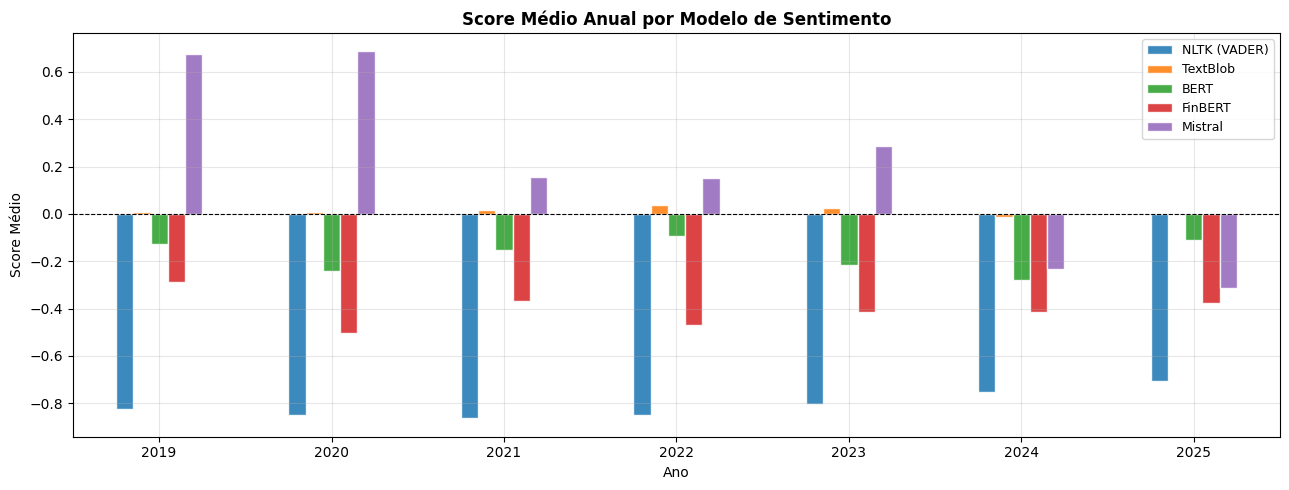

,NLTK (VADER),TextBlob,BERT,FinBERT,Mistral
ano,,,,,
2019,-0.8258,0.0078,-0.1261,-0.2887,0.6750
2020,-0.8491,0.0073,-0.2396,-0.5041,0.6875
2021,-0.8636,0.0156,-0.1530,-0.3675,0.1562
2022,-0.8473,0.0387,-0.0945,-0.4713,0.1500
2023,-0.8032,0.0238,-0.2143,-0.4145,0.2857
2024,-0.7502,-0.0139,-0.2812,-0.4128,-0.2333
2025,-0.7058,0.0014,-0.1116,-0.3753,-0.3125


In [11]:
df['ano'] = df['data'].dt.year
df_anual = df.groupby('ano')[MODELOS].mean().round(4)
df_anual.columns = LABELS

fig, ax = plt.subplots(figsize=(13, 5))
df_anual.plot(kind='bar', ax=ax, color=CORES, edgecolor='white', alpha=0.87)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Score Médio Anual por Modelo de Sentimento',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Score Médio')
ax.legend(fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df_anual

## 10. Classificação de Sentimento por Modelo

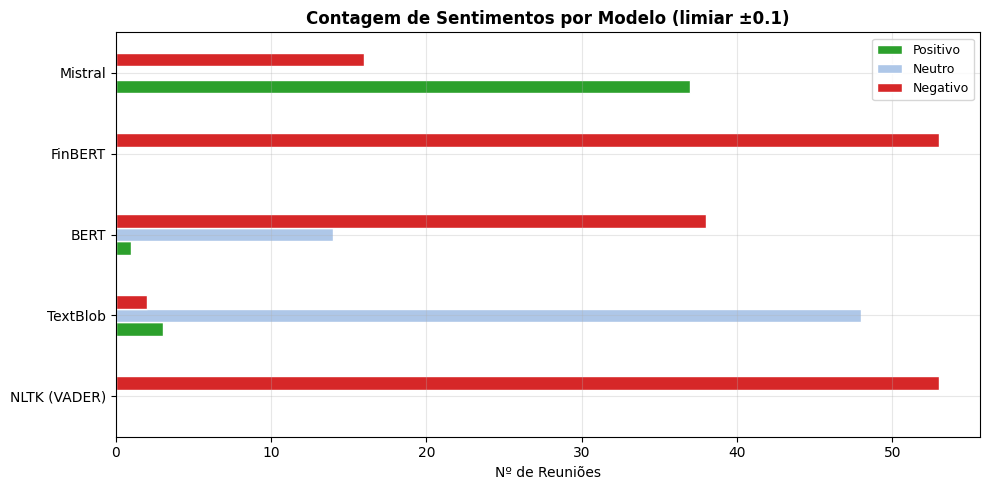

,Negativo,Neutro,Positivo
NLTK (VADER),53,0,0
TextBlob,2,48,3
BERT,38,14,1
FinBERT,53,0,0
Mistral,16,0,37


In [12]:
def classificar(score, limiar=0.1):
    if score > limiar:   return 'Positivo'
    elif score < -limiar: return 'Negativo'
    else:                return 'Neutro'

contagens = {}
for col, label in zip(MODELOS, LABELS):
    cats = df[col].apply(classificar).value_counts()
    contagens[label] = cats

df_cats = pd.DataFrame(contagens).T.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
df_cats[['Positivo', 'Neutro', 'Negativo']].plot(
    kind='barh', ax=ax,
    color=['#2ca02c', '#aec7e8', '#d62728'],
    edgecolor='white'
)
ax.set_title('Contagem de Sentimentos por Modelo (limiar ±0.1)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Reuniões')
ax.set_ylabel('')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

df_cats

# Análise Comparativa de Sentimento: Estatisticas

Este notebook unifica as bases de análise de sentimento das Atas do COPOM,
inserindo o score do modelo **Mistral** e comparando todos os modelos:
- **NLTK** (VADER)
- **TextBlob**
- **BERT** (BERTimbau)
- **FinBERT**
- **Mistral** (LLM)

Período: **2019 – 2025**

In [13]:
# Carrega base sem Mistral
df_base = pd.read_csv('base_sentimentos_estatisticas_sem_mistral.csv')

# Remove colunas de índice exportadas anteriormente, se existirem
df_base = df_base.loc[:, ~df_base.columns.str.contains('^unnamed', case=False)]

# Carrega scores Mistral
df_mistral = pd.read_csv('base_sentimento_estatisticas.csv')[['data', 'score']].rename(
    columns={'score': 'score_mistral'}
)

# Converte data antes do merge para garantir compatibilidade entre as bases
df_base['data'] = pd.to_datetime(df_base['data'])
df_mistral['data'] = pd.to_datetime(df_mistral['data'])

# Remove duplicidades por data, caso existam em alguma leitura anterior
df_base = df_base.drop_duplicates(subset=['data']).copy()
df_mistral = df_mistral.drop_duplicates(subset=['data']).copy()

# Merge pela coluna 'data'
df = df_base.merge(df_mistral, on='data', how='left', validate='one_to_one')

# Organiza colunas finais
df = df[['data', 'arquivo', 'tipo', 'score_nltk', 'score_textblob',
         'score_bert', 'score_finbert', 'score_mistral']]

# Ordena a base
df = df.sort_values('data').reset_index(drop=True)

# Validação rápida
print(f'Registros: {len(df)}')
print(f'Período: {df.data.min().date()} → {df.data.max().date()}')
print(f'Scores Mistral ausentes: {df["score_mistral"].isna().sum()}')

df.head()


Registros: 81
Período: 2019-01-01 → 2025-12-01
Scores Mistral ausentes: 0


,data,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-01-01,201901_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9969,-0.145455,-1.0,0.335325,-0.3
1,2019-02-01,201902_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9872,-0.400000,-0.5,-0.266386,-0.6
2,2019-03-01,201903_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9911,-0.320000,-1.0,0.278030,-0.3
3,2019-04-01,201904_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9934,-0.400000,-1.0,0.407023,-0.5
4,2019-05-01,201905_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9903,0.000000,-1.0,-0.195990,-0.5


In [14]:
desc = df[MODELOS].describe().T
desc.index = LABELS
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4)

,mean,std,min,25%,50%,75%,max
NLTK (VADER),-0.9877,0.0051,-0.9974,-0.9911,-0.9884,-0.9859,-0.9698
TextBlob,-0.0259,0.2221,-0.5333,-0.2000,0.0000,0.1000,0.7000
BERT,-0.9051,0.1374,-1.0000,-1.0000,-1.0000,-0.8750,-0.5000
FinBERT,0.0623,0.2362,-0.5469,-0.0851,0.0872,0.2363,0.5889
Mistral,-0.1821,0.3880,-0.7000,-0.5000,-0.2500,-0.1500,0.8000


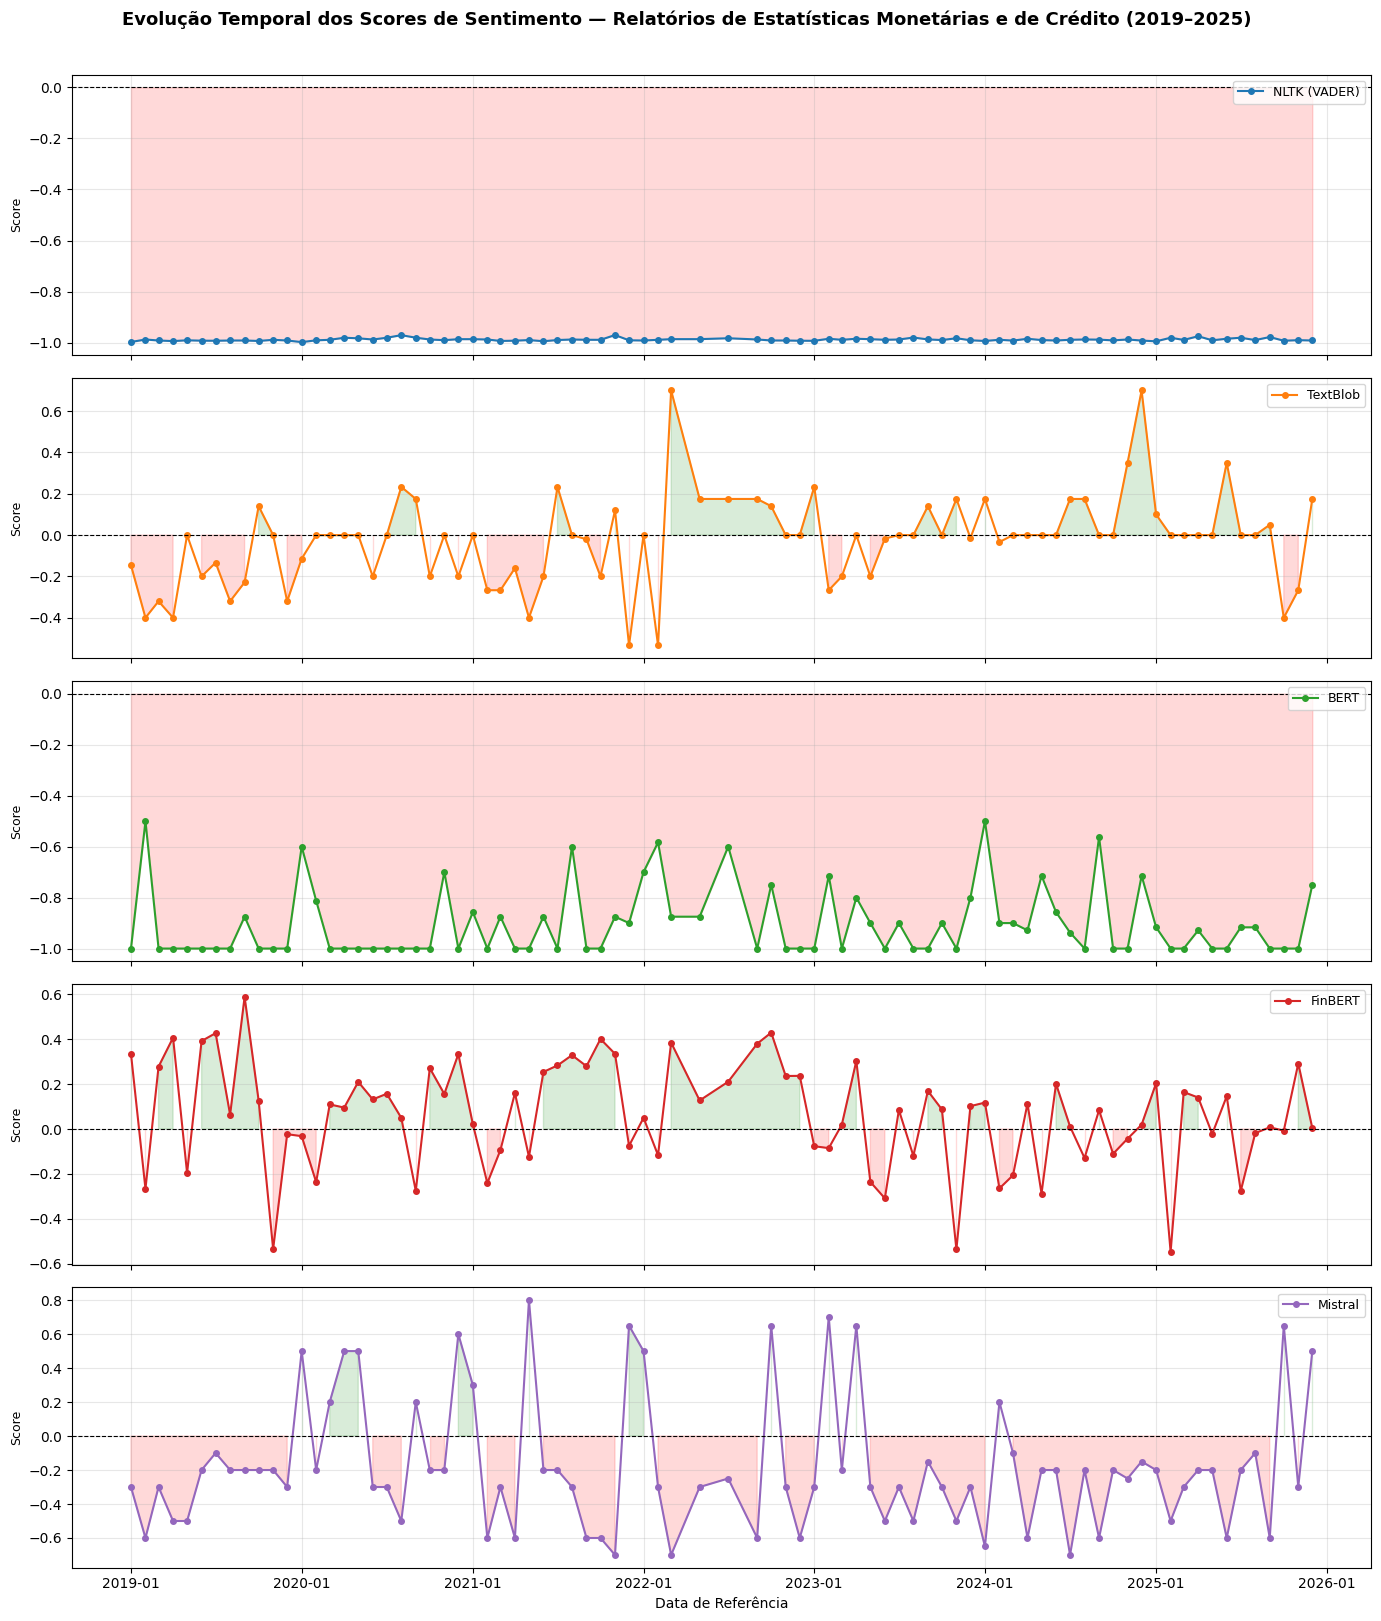

In [15]:
fig, axes = plt.subplots(len(MODELOS), 1, figsize=(14, 16), sharex=True)

for ax, col, label, cor in zip(axes, MODELOS, LABELS, CORES):
    ax.plot(df['data'], df[col], marker='o', markersize=4,
            linewidth=1.5, color=cor, label=label)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.fill_between(df['data'], df[col], 0,
                    where=df[col] >= 0, alpha=0.15, color='green')
    ax.fill_between(df['data'], df[col], 0,
                    where=df[col] < 0, alpha=0.15, color='red')
    ax.set_ylabel('Score', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[-1].set_xlabel('Data de Referência')
fig.suptitle('Evolução Temporal dos Scores de Sentimento — Relatórios de Estatísticas Monetárias e de Crédito (2019–2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


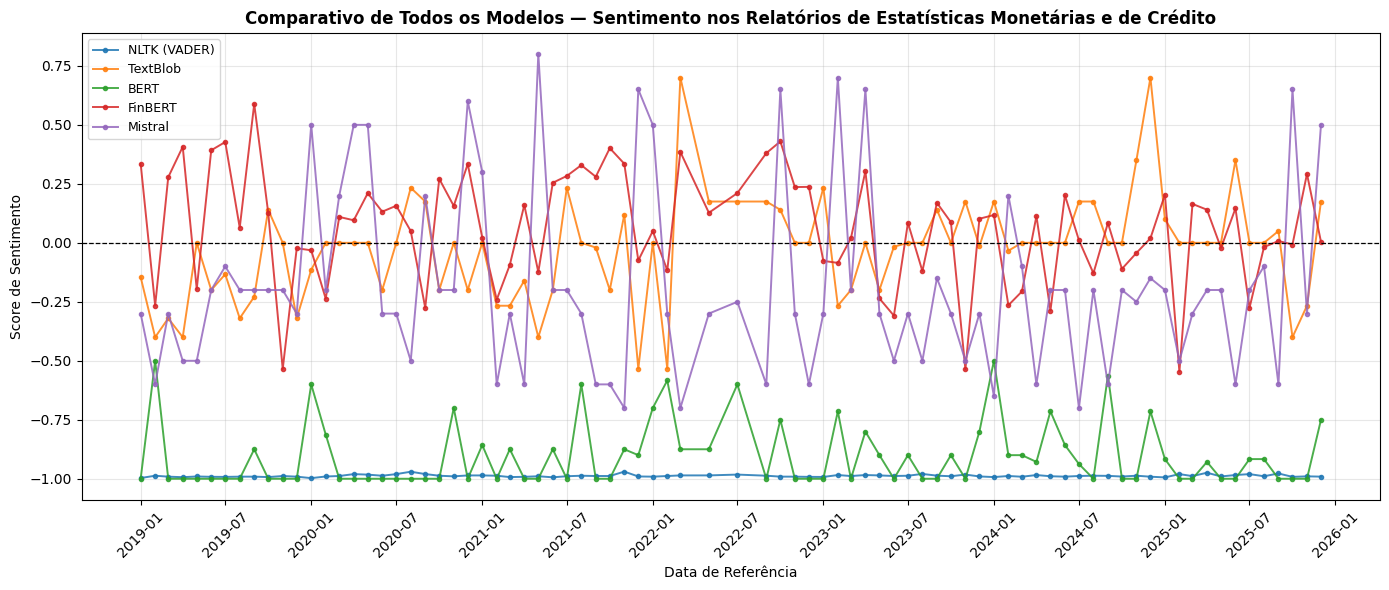

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

for col, label, cor in zip(MODELOS, LABELS, CORES):
    ax.plot(df['data'], df[col], marker='o', markersize=3,
            linewidth=1.4, label=label, color=cor, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('Comparativo de Todos os Modelos — Sentimento nos Relatórios de Estatísticas Monetárias e de Crédito',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data de Referência')
ax.set_ylabel('Score de Sentimento')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


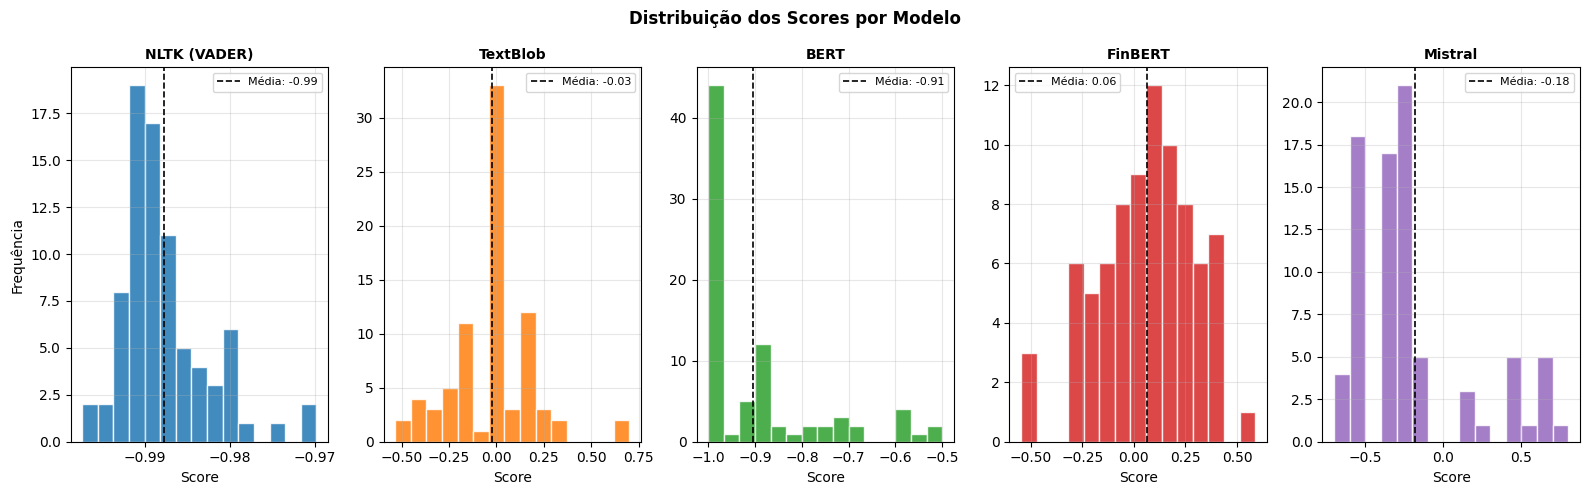

In [17]:
fig, axes = plt.subplots(1, len(MODELOS), figsize=(16, 5), sharey=False)

for ax, col, label, cor in zip(axes, MODELOS, LABELS, CORES):
    ax.hist(df[col], bins=15, color=cor, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--',
               linewidth=1.2, label=f'Média: {df[col].mean():.2f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frequência')
fig.suptitle('Distribuição dos Scores por Modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3646/91079229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Modelo', y='Score', palette=CORES, ax=ax)


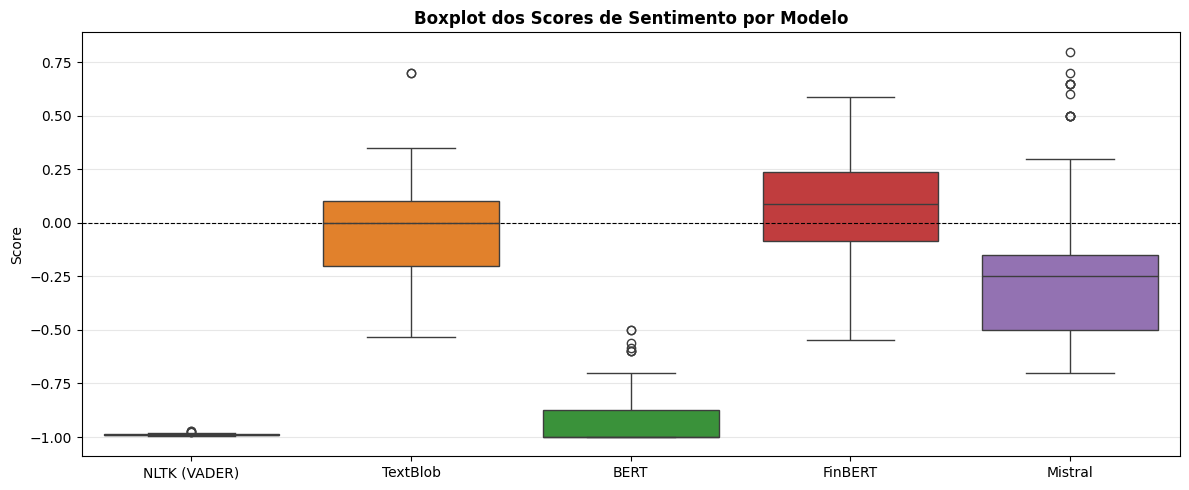

In [18]:
df_melt = df[MODELOS].copy()
df_melt.columns = LABELS
df_long = df_melt.melt(var_name='Modelo', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_long, x='Modelo', y='Score', palette=CORES, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Boxplot dos Scores de Sentimento por Modelo', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

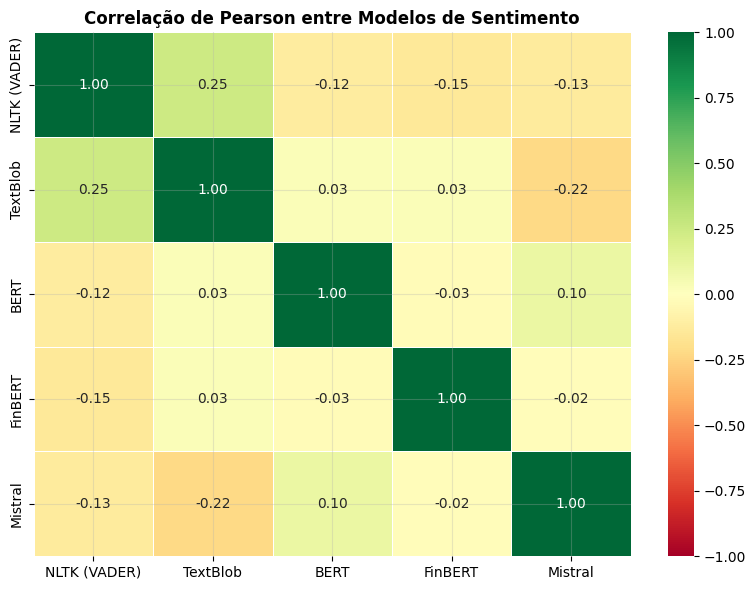

In [19]:
corr_matrix = df[MODELOS].corr(method='pearson')
corr_matrix.index   = LABELS
corr_matrix.columns = LABELS

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlação de Pearson entre Modelos de Sentimento',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Tabela de correlações: Pearson e Spearman
resultados = []
for i, (col_a, lab_a) in enumerate(zip(MODELOS, LABELS)):
    for col_b, lab_b in zip(MODELOS[i+1:], LABELS[i+1:]):
        r_p, p_p = pearsonr(df[col_a], df[col_b])
        r_s, p_s = spearmanr(df[col_a], df[col_b])
        resultados.append({
            'Modelo A': lab_a, 'Modelo B': lab_b,
            'Pearson r': round(r_p, 3), 'p-valor (P)': round(p_p, 4),
            'Spearman ρ': round(r_s, 3), 'p-valor (S)': round(p_s, 4)
        })

pd.DataFrame(resultados)

,Modelo A,Modelo B,Pearson r,p-valor (P),Spearman ρ,p-valor (S)
0,NLTK (VADER),TextBlob,0.245,0.0272,0.297,0.0071
1,NLTK (VADER),BERT,-0.124,0.2718,-0.077,0.4936
2,NLTK (VADER),FinBERT,-0.145,0.1958,-0.158,0.1582
3,NLTK (VADER),Mistral,-0.131,0.2435,-0.163,0.1456
4,TextBlob,BERT,0.028,0.8046,0.056,0.6185
5,TextBlob,FinBERT,0.028,0.8041,0.012,0.9180
6,TextBlob,Mistral,-0.223,0.0459,-0.135,0.2300
7,BERT,FinBERT,-0.028,0.8020,-0.054,0.6329
8,BERT,Mistral,0.102,0.3653,0.129,0.2519
9,FinBERT,Mistral,-0.017,0.8822,-0.084,0.4538


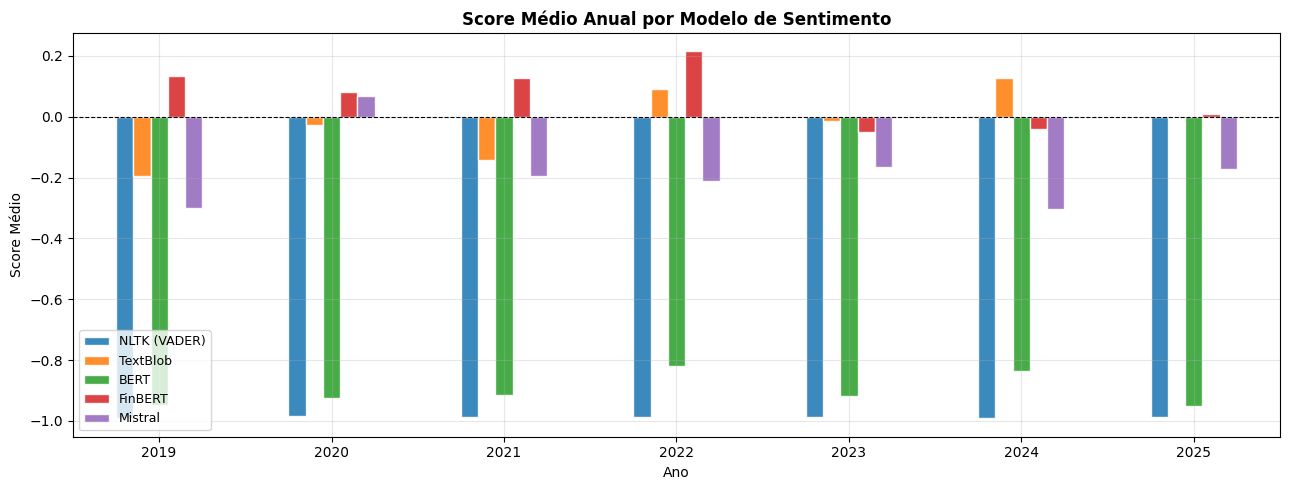

,NLTK (VADER),TextBlob,BERT,FinBERT,Mistral
ano,,,,,
2019,-0.9914,-0.1939,-0.9479,0.1333,-0.3000
2020,-0.9850,-0.0255,-0.9260,0.0810,0.0667
2021,-0.9879,-0.1411,-0.9152,0.1277,-0.1958
2022,-0.9883,0.0924,-0.8204,0.2155,-0.2111
2023,-0.9866,-0.0124,-0.9179,-0.0496,-0.1667
2024,-0.9891,0.1285,-0.8345,-0.0412,-0.3042
2025,-0.9860,0.0007,-0.9524,0.0075,-0.1708


In [21]:
df['ano'] = df['data'].dt.year
df_anual = df.groupby('ano')[MODELOS].mean().round(4)
df_anual.columns = LABELS

fig, ax = plt.subplots(figsize=(13, 5))
df_anual.plot(kind='bar', ax=ax, color=CORES, edgecolor='white', alpha=0.87)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Score Médio Anual por Modelo de Sentimento',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Score Médio')
ax.legend(fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df_anual

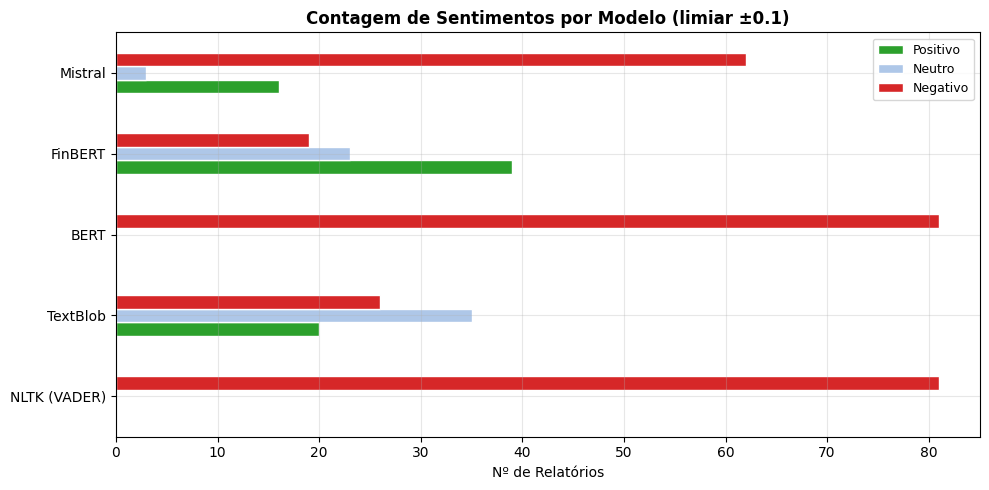

,Negativo,Neutro,Positivo
NLTK (VADER),81,0,0
TextBlob,26,35,20
BERT,81,0,0
FinBERT,19,23,39
Mistral,62,3,16


In [22]:
def classificar(score, limiar=0.1):
    if score > limiar:   return 'Positivo'
    elif score < -limiar: return 'Negativo'
    else:                return 'Neutro'

contagens = {}
for col, label in zip(MODELOS, LABELS):
    cats = df[col].apply(classificar).value_counts()
    contagens[label] = cats

df_cats = pd.DataFrame(contagens).T.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
df_cats[['Positivo', 'Neutro', 'Negativo']].plot(
    kind='barh', ax=ax,
    color=['#2ca02c', '#aec7e8', '#d62728'],
    edgecolor='white'
)
ax.set_title('Contagem de Sentimentos por Modelo (limiar ±0.1)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Relatórios')
ax.set_ylabel('')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

df_cats


## 11. Unificação e Exportação da Base final consolidada

In [23]:
# Junta as bases finais de sentimento: Atas do Copom + Relatórios de Estatísticas

def montar_base_sentimento(arquivo_base_sem_mistral, arquivo_mistral, tipo_relatorio):
    """
    Lê a base de sentimentos sem Mistral, junta com a base de scores do Mistral
    e cria uma coluna identificando o tipo de relatório.
    """
    # Base com NLTK, TextBlob, BERT e FinBERT
    df_base = pd.read_csv(arquivo_base_sem_mistral)
    df_base = df_base.loc[:, ~df_base.columns.str.contains('^unnamed', case=False)]
    df_base = df_base.drop(columns=['score_mistral'], errors='ignore')

    # Base com score do Mistral
    df_mistral = pd.read_csv(arquivo_mistral)[['data', 'score']].rename(
        columns={'score': 'score_mistral'}
    )

    # Padroniza datas para permitir o merge
    df_base['data'] = pd.to_datetime(df_base['data'])
    df_mistral['data'] = pd.to_datetime(df_mistral['data'])

    # Remove duplicidades por segurança
    df_base = df_base.drop_duplicates(subset=['data']).copy()
    df_mistral = df_mistral.drop_duplicates(subset=['data']).copy()

    # Junta os scores do Mistral com a base dos demais modelos
    df_unificado = df_base.merge(
        df_mistral,
        on='data',
        how='left',
        validate='one_to_one'
    )

    # Identifica a origem do relatório
    df_unificado['tipo_relatorio'] = tipo_relatorio

    # Organiza colunas finais
    colunas_finais = [
        'data',
        'tipo_relatorio',
        'arquivo',
        'tipo',
        'score_nltk',
        'score_textblob',
        'score_bert',
        'score_finbert',
        'score_mistral'
    ]

    return df_unificado[colunas_finais]


# Base das Atas do Copom
df_copom = montar_base_sentimento(
    arquivo_base_sem_mistral='base_sentimentos_copom_sem_mistral.csv',
    arquivo_mistral='base_sentimento_copom.csv',
    tipo_relatorio='copom'
)

# Base dos Relatórios de Estatísticas Monetárias e de Crédito
df_estatisticas = montar_base_sentimento(
    arquivo_base_sem_mistral='base_sentimentos_estatisticas_sem_mistral.csv',
    arquivo_mistral='base_sentimento_estatisticas.csv',
    tipo_relatorio='estatisticas'
)

# Concatena as duas bases em uma base final consolidada
df_final = pd.concat([df_copom, df_estatisticas], ignore_index=True)
df_final = df_final.sort_values(['tipo_relatorio', 'data']).reset_index(drop=True)

print(f'Registros Copom: {len(df_copom)}')
print(f'Registros Estatísticas: {len(df_estatisticas)}')
print(f'Registros totais na base final: {len(df_final)}')
print(f'Scores Mistral ausentes na base final: {df_final["score_mistral"].isna().sum()}')

df_final.head()



Registros Copom: 53
Registros Estatísticas: 81
Registros totais na base final: 134
Scores Mistral ausentes na base final: 0


,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.7783,0.0000,-0.071429,-0.248734,0.50
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.6808,0.0000,-0.062500,-0.336417,0.50
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.9274,0.0625,-0.125000,-0.388865,0.65
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.7783,0.0000,-0.187500,-0.407422,0.75
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.8402,0.0000,0.062500,-0.227865,0.75


In [24]:
# Exporta a base final consolidada
df_export = df_final.copy()
df_export['data'] = df_export['data'].dt.strftime('%Y-%m-%d')

df_export.to_csv('base_sentimentos.csv', index=False)

print(f'Arquivo base_sentimentos.csv exportado com {len(df_export)} registros.')
df_export


Arquivo base_sentimentos.csv exportado com 134 registros.


,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.7783,0.000000,-0.071429,-0.248734,0.50
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.6808,0.000000,-0.062500,-0.336417,0.50
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.9274,0.062500,-0.125000,-0.388865,0.65
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.7783,0.000000,-0.187500,-0.407422,0.75
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.8402,0.000000,0.062500,-0.227865,0.75
...,...,...,...,...,...,...,...,...,...
129,2025-08-01,estatisticas,202508_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9894,0.000000,-0.916667,-0.018209,-0.10
130,2025-09-01,estatisticas,202509_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9776,0.050000,-1.000000,0.007749,-0.60
131,2025-10-01,estatisticas,202510_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9920,-0.400000,-1.000000,-0.007200,0.65
132,2025-11-01,estatisticas,202511_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9898,-0.266667,-1.000000,0.292047,-0.30
